# Machine Learning Assignment - G00415845
 
## Workflow
1. Data Loading & Understanding
2. Data Preprocessing
3. Train / Validation / Test Split
4. Model Training & Tuning
5. Model Comparison & Selection
6. Final Model Evaluation

## 1. Setup

Setting up the environment with required libraries and a fixed random seed for reproducibility.

In [37]:
# Core
import numpy as np
import pandas as pd

# Image processing
from PIL import Image

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models (we will use these later)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Misc
import time
import os
import json
from datetime import datetime
from pathlib import Path

# TensorFlow (for deep learning models)
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [10]:
RANDOM_STATE = 415845
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [11]:
os.makedirs("logs", exist_ok=True)

def log_run(model_name, params, start_time, end_time, train_acc, val_acc, notes=""):
    
    duration = end_time - start_time
    log_file = "logs/experiment_log.txt"
    
    # Check if the model run is already logged to prevent duplicates
    log_content = ""
    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            log_content = f.read()
            
    if f"Model: {model_name}" in log_content:
        print(f"'{model_name}' is already in the log file. Skipping.")
        return

    entry = f"""
========================================
Time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
Model: {model_name}
Parameters: {params}
Training Time (s): {duration:.2f}
Train Accuracy: {train_acc:.4f}
Validation Accuracy: {val_acc:.4f}
Notes: {notes}
========================================
"""
    
    with open(log_file, "a") as f:
        f.write(entry)
    print(f"Logged results for '{model_name}'.")

In [12]:
results_df = pd.DataFrame(columns=[
    "Model",
    "Parameters",
    "Train Accuracy",
    "Validation Accuracy",
    "Training Time (s)",
    "Overfitting (Train - Val)",
    "Notes"
])


In [13]:
def add_to_results(df, model_name, params, train_acc, val_acc, training_time, notes=""):
    """
    Adds a new row to the results DataFrame and prevents duplicates.
    """

    # Check if the model is already in the dataframe
    if model_name in df["Model"].values:
        print(f"'{model_name}' is already in the results table. Skipping.")
        return df

    # Calculate overfitting
    overfitting = train_acc - val_acc
    
    # Create a new row as a dictionary
    new_row = {
        "Model": model_name,
        "Parameters": str(params),  # Convert params dict to string for display
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Training Time (s)": training_time,
        "Overfitting (Train - Val)": overfitting,
        "Notes": notes
    }
    
    # Append the new row
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    
    # Save the updated dataframe to a csv file
    df.to_csv("logs/results.csv", index=False)
    
    print(f"Added '{model_name}' to the results table.")
    return df

results_df = pd.read_csv("cnn_results.csv")

## 2. Data Loading and Understanding

Loading and exploring the garbage classification dataset with 10 waste categories stored in separate folders.

In [14]:
data_dir = Path("../data/garbage/garbage")

print("Dataset exists:", data_dir.exists())
print("Dataset path:", data_dir.resolve())

Dataset exists: True
Dataset path: C:\Users\norak\Desktop\ML-Assingment G00415845\data\garbage\garbage


In [15]:
# Set up parameters for loading the dataset
IMAGE_SIZE = (128, 128) # will resize all images to this size for consistency
BATCH_SIZE = 32 # will use a batch size of 32 for training our models

# Load the dataset using Keras utility
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.


### Class Distribution and Imbalance

The dataset shows ~4x imbalance between the largest class (clothes: 1892) and smallest (trash: 453), which will be monitored using class-wise metrics.

In [16]:
# Class distribution
class_names = [d.name for d in data_dir.iterdir() if d.is_dir()]
class_counts = {}

for class_name in class_names:
    class_path = data_dir / class_name
    image_files = [f for f in class_path.iterdir() if f.is_file()]
    class_counts[class_name] = len(image_files)

class_counts

{'battery': 756,
 'biological': 699,
 'cardboard': 1411,
 'clothes': 1892,
 'glass': 1736,
 'metal': 930,
 'paper': 1336,
 'plastic': 1597,
 'shoes': 1449,
 'trash': 453}

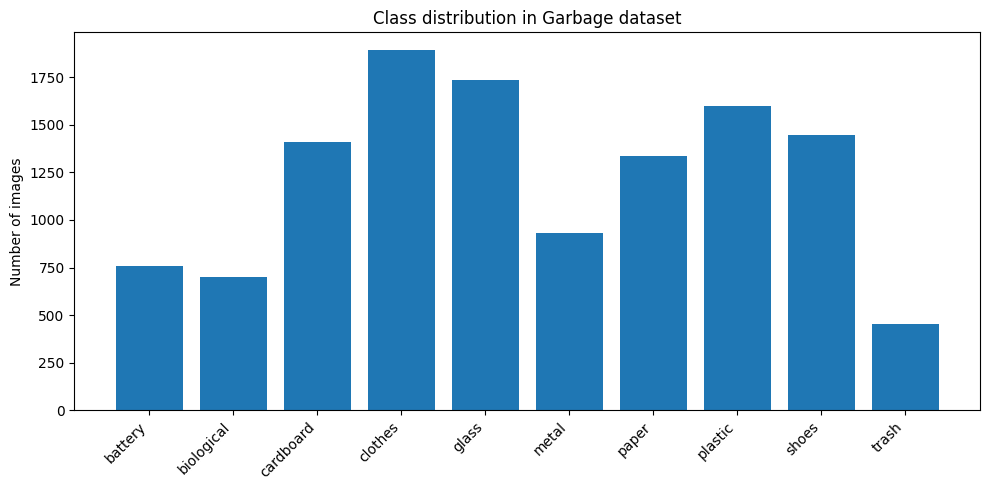

In [17]:
# Visualize class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution in Garbage dataset")
plt.tight_layout()
plt.show()

### Dataset Samples & Pixel Range

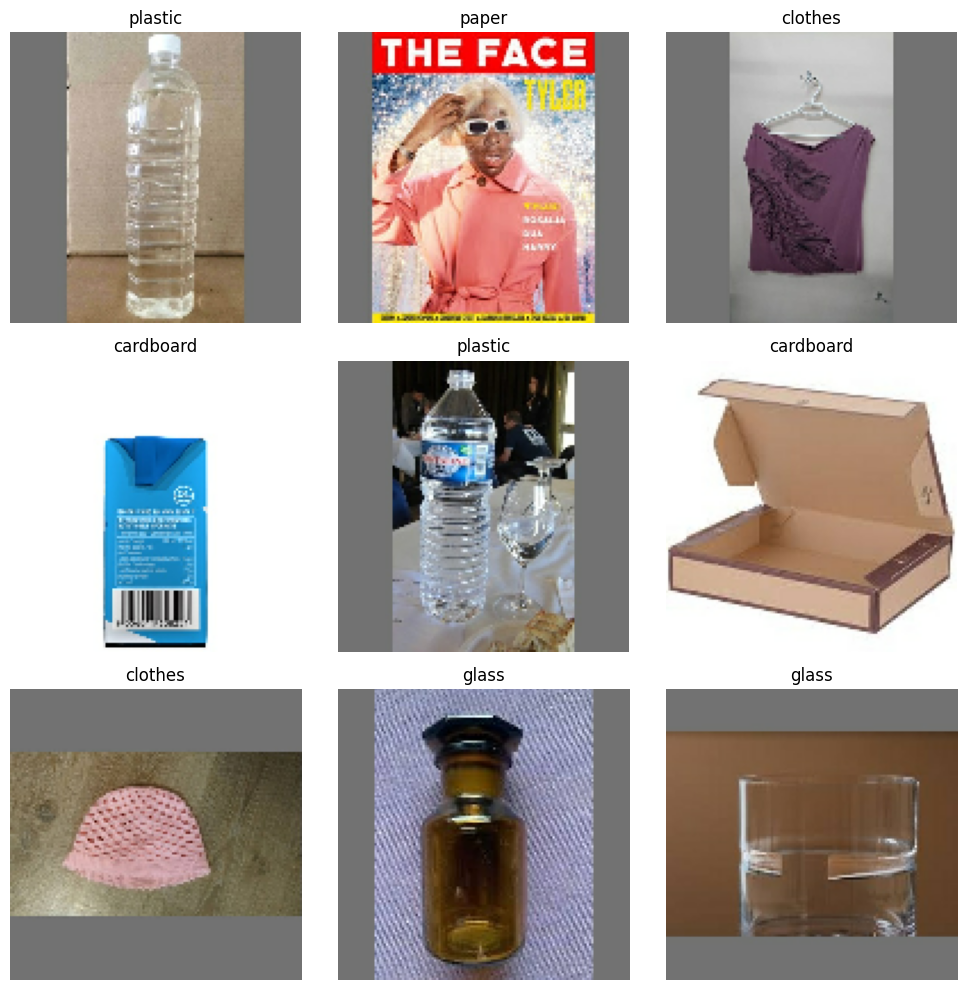

In [13]:
# Sample some images from the dataset
images_batch, labels_batch = next(iter(full_ds))

plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    plt.title(full_ds.class_names[labels_batch[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Check pixel value range and dtype

print("Pixel dtype:", images_batch.dtype)
print("Min pixel value:", tf.reduce_min(images_batch).numpy())
print("Max pixel value:", tf.reduce_max(images_batch).numpy())

Pixel dtype: <dtype: 'float32'>
Min pixel value: 0.0
Max pixel value: 255.0


### Data Quality

Checking for corrupted images in the dataset.

In [14]:
# Check for corrupted images

bad_files = []

for class_name in class_names:
    class_path = data_dir / class_name
    for file_path in class_path.iterdir():
        try:
            with Image.open(file_path) as img:
                img.verify()  # check if image is valid
        except Exception:
            bad_files.append(file_path)

print("Number of corrupted images:", len(bad_files))

Number of corrupted images: 0


## 3. Train, Validation, and Test Split

Splitting data into 70% training, 10% validation, and 20% test sets with fixed random seed for reproducibility.

In [18]:
# First Split: Train (70%) and Temporary (30%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [19]:
# Second Split: split Temporary into Validation (10%) and Test (20%)
temp_size = tf.data.experimental.cardinality(temp_ds).numpy()  # number of batches
val_size = temp_size // 3  # exactly 1/3 of temp 

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [20]:
# Check sizes
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Validation batches:", val_batches)
print("Test batches:", test_batches)

print("-------------------------------")
print("Approx total samples:")
print("Train:", train_batches * BATCH_SIZE)
print("Validation:", val_batches * BATCH_SIZE)
print("Test:", test_batches * BATCH_SIZE)

Train batches: 269
Validation batches: 38
Test batches: 77
-------------------------------
Approx total samples:
Train: 8608
Validation: 1216
Test: 2464


## 4. Preprocessing

Normalizing pixel values to [0,1] and preparing the dataset for model training.

In [19]:
# An initial image size of (128, 128) selected to reduce computational cost.
IMAGE_SIZE = (128, 128)

In [21]:
# Normalisation layer to scale pixel values to [0, 1]
normalisation_layer = layers.Rescaling(1./255)

In [22]:
# Apply normalization to all datasets
train_ds = train_ds.map(lambda x, y: (normalisation_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalisation_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalisation_layer(x), y))

## 5. CNN From Scratch

Building and training custom CNN models to establish a baseline, then experimenting with dropout, data augmentation, architecture variations, and grayscale vs RGB inputs.

### 5.1 Baseline CNN (RGB, 128×128)

Starting with a simple 3-layer CNN to establish a baseline and identify overfitting issues.

In [23]:
model = models.Sequential()

# Input layer
model.add(layers.Input(shape=(128, 128, 3)))

# Convolutional Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten and Dense layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))

# Output layer
model.add(layers.Dense(len(class_names), activation='softmax'))

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train the model and measure training time
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

end_time = time.time()
training_time = end_time - start_time

# Extract final metrics
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Training time:", training_time)


Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 62s 221ms/step - accuracy: 0.3945 - loss: 1.7277 - val_accuracy: 0.5255 - val_loss: 1.3265
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 57s 209ms/step - accuracy: 0.5693 - loss: 1.2494 - val_accuracy: 0.5798 - val_loss: 1.2357
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 56s 206ms/step - accuracy: 0.6595 - loss: 1.0172 - val_accuracy: 0.6094 - val_loss: 1.2056
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 55s 202ms/step - accuracy: 0.7363 - loss: 0.7834 - val_accuracy: 0.6390 - val_loss: 1.1577
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 58s 216ms/step - accuracy: 0.8055 - loss: 0.5734 - val_accuracy: 0.6472 - val_loss: 1.2430
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 58s 216ms/step - accuracy: 0.8594 - loss: 0.4126 - val_accuracy: 0.6505 - val_loss: 1.4158
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 58s 215ms/step - accuracy: 0.9019 - loss: 0.2916 - val_accuracy: 0.6414 - val_loss: 1.6443
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 59s 217ms/step - accuracy: 0.9303 - loss: 0

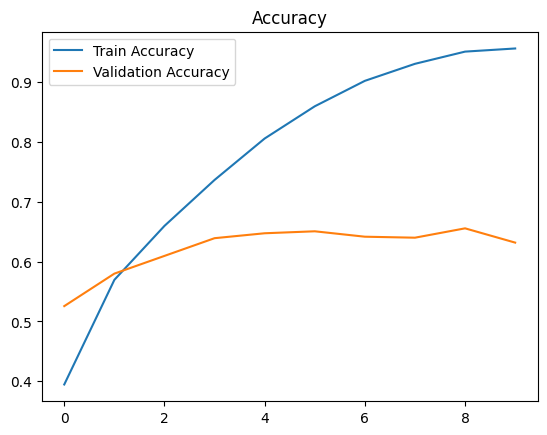

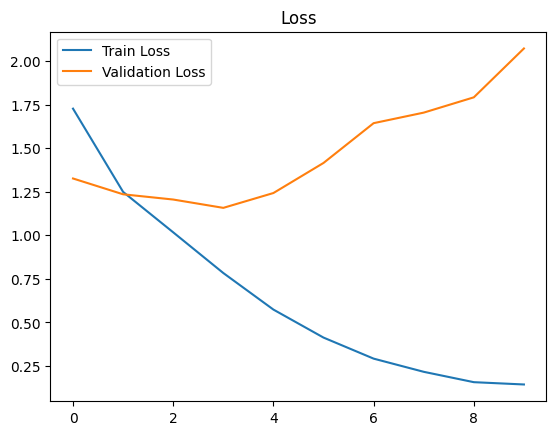

In [26]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [27]:
# Evaluation
train_loss, train_acc = model.evaluate(train_ds)
val_loss, val_acc = model.evaluate(val_ds)

269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.9574 - loss: 0.1374
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6382 - loss: 1.9885


In [ ]:
# Log to text file

log_run(
    model_name="Baseline CNN",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": 10
    },
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Initial baseline CNN trained on RGB images"
)

# Add to results dataframe
results_df = add_to_results(
    df=results_df,
    model_name="Baseline CNN",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": 10
    },
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Initial baseline CNN trained on RGB images"
)

results_df

Logged results for 'Baseline CNN'.
Added 'Baseline CNN' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.957353,0.638158,597.713912,0.319195,Initial baseline CNN trained on RGB images


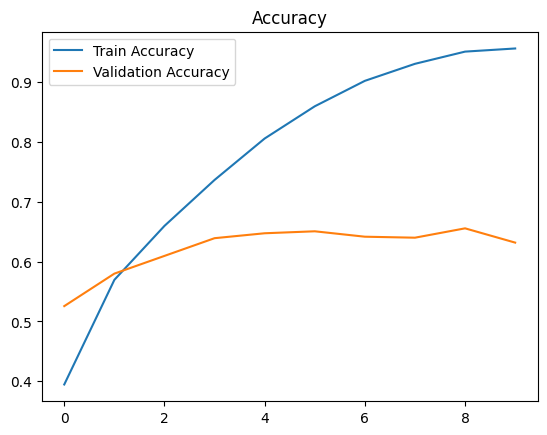

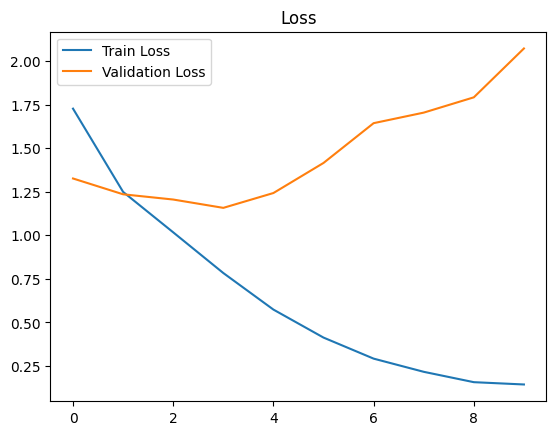

In [29]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

The baseline CNN achieved 95.7% training accuracy but only 63.8% validation accuracy, clearly indicating overfitting that needs to be addressed with regularization techniques.

### 5.2 CNN with Dropout

Adding 0.2 dropout regularization to reduce overfitting and improve validation accuracy.

In [30]:
model_dropout2 = models.Sequential()

# Input - same as before to ensure fair comparison
model_dropout2.add(layers.Input(shape=(128, 128, 3)))

# Conv blocks
model_dropout2.add(layers.Conv2D(32, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

model_dropout2.add(layers.Conv2D(64, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

model_dropout2.add(layers.Conv2D(128, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

# Dense
model_dropout2.add(layers.Flatten())
model_dropout2.add(layers.Dense(128, activation='relu'))

# Dropout added
model_dropout2.add(layers.Dropout(0.2))

# Output
model_dropout2.add(layers.Dense(len(class_names), activation='softmax'))

In [31]:
# Compile
model_dropout2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
start_time = time.time()

history_dropout = model_dropout2.fit(
    train_ds,
    validation_data=val_ds,
    epochs= 10
)

end_time = time.time()
training_time = end_time - start_time

# Evaluate
train_loss, train_acc = model_dropout2.evaluate(train_ds)
val_loss, val_acc = model_dropout2.evaluate(val_ds)



Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 57s 204ms/step - accuracy: 0.3640 - loss: 1.8013 - val_accuracy: 0.4317 - val_loss: 1.6279
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 59s 218ms/step - accuracy: 0.5435 - loss: 1.3410 - val_accuracy: 0.5765 - val_loss: 1.2237
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 56s 209ms/step - accuracy: 0.6176 - loss: 1.1148 - val_accuracy: 0.6505 - val_loss: 1.0961
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 56s 207ms/step - accuracy: 0.6698 - loss: 0.9687 - val_accuracy: 0.6530 - val_loss: 1.0824
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 58s 217ms/step - accuracy: 0.7285 - loss: 0.8011 - val_accuracy: 0.5831 - val_loss: 1.3340
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 57s 211ms/step - accuracy: 0.7603 - loss: 0.6976 - val_accuracy: 0.6497 - val_loss: 1.2302
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 56s 209ms/step - accuracy: 0.8065 - loss: 0.5517 - val_accuracy: 0.6538 - val_loss: 1.2880
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 57s 213ms/step - accuracy: 0.8444 - loss: 0

In [32]:
# Log
log_run(
    model_name="CNN + Dropout (0.2)",
    params={"epochs": 10, "dropout": 0.2},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Added dropout to reduce overfitting"
)

# Results table
results_df = add_to_results(
    df=results_df,
    model_name="CNN + Dropout (0.2)",
    params={"epochs": 10, "dropout": 0.2},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Dropout added"
)

Logged results for 'CNN + Dropout (0.2)'.
Added 'CNN + Dropout (0.2)' to the results table.


Dropout improved validation accuracy to 65.5% (from 63.8%), showing modest gains in generalization at the cost of slightly lower training accuracy.

### 5.3 CNN with Reduced Image Size (64×64)

In [9]:
IMAGE_SIZE = (64, 64)

In [10]:
# New Split: Train (70%) and Temporary (30%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Second Split: split Temporary into Validation (10%) and Test (20%)
temp_size = tf.data.experimental.cardinality(temp_ds).numpy()
val_size = temp_size // 3

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

# Normalisation layer to scale pixel values to [0, 1]
normalisation_layer = layers.Rescaling(1./255)

# Apply normalization to all datasets
train_ds = train_ds.map(lambda x, y: (normalisation_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalisation_layer(x), y))   
test_ds = test_ds.map(lambda x, y: (normalisation_layer(x), y))


Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [17]:

model_img64 = models.Sequential()

# Input layer
model_img64.add(layers.Input(shape=(64, 64, 3)))

# Convolutional Block 1
model_img64.add(layers.Conv2D(32, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 2
model_img64.add(layers.Conv2D(64, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 3
model_img64.add(layers.Conv2D(128, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Flatten and Dense layers
model_img64.add(layers.Flatten())
model_img64.add(layers.Dense(128, activation='relu'))

# Output layer
model_img64.add(layers.Dense(len(class_names), activation='softmax'))

In [36]:
# Compile
model_img64.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
# Train the model and measure training time
start_time = time.time()

historyimg64 = model_img64.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

end_time = time.time()
training_time = end_time - start_time

print("Training time:", training_time)


Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.3911 - loss: 1.7330 - val_accuracy: 0.5123 - val_loss: 1.3862
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.5428 - loss: 1.3047 - val_accuracy: 0.5831 - val_loss: 1.2074
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.6256 - loss: 1.1081 - val_accuracy: 0.5872 - val_loss: 1.1899
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.6751 - loss: 0.9576 - val_accuracy: 0.6160 - val_loss: 1.1549
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.7322 - loss: 0.8006 - val_accuracy: 0.6488 - val_loss: 1.1531
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.7706 - loss: 0.6725 - val_accuracy: 0.6530 - val_loss: 1.1616
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.8101 - loss: 0.5528 - val_accuracy: 0.6801 - val_loss: 1.1506
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.8602 - loss: 0.4240 - 

In [38]:
# Evaluation
train_loss, train_acc = model_img64.evaluate(train_ds)
val_loss, val_acc = model_img64.evaluate(val_ds)

269/269 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9245 - loss: 0.2224
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6743 - loss: 1.4737


In [ ]:
# Log to text file

log_run(
    model_name="Baseline CNN (64 x 64 img) RERUN!",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": 10
    },
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Initial baseline CNN trained on 64x64 images"
)

# Add to results dataframe
results_df = add_to_results(
    df=results_df,
    model_name="Baseline CNN (64 x 64 img) RERUN!",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": 10
    },
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Initial baseline CNN trained on 64x64 images"
)

results_df

Logged results for 'Baseline CNN (64 x 64 img) RERUN!'.
Added 'Baseline CNN (64 x 64 img) RERUN!' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.957353,0.638158,597.713912,0.319195,Initial baseline CNN trained on RGB images
1,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.947099,0.655428,567.528332,0.291671,Dropout added
2,Baseline CNN (64 x 64 img) RERUN!,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.924493,0.674342,152.456785,0.250151,Initial baseline CNN trained on 64x64 images


Reducing to 64×64 images improved validation accuracy to 67.4% while reducing training time and overfitting.

### 5.4 CNN with Data Augmentation

In [22]:
# Data augmentation pipeline (for training dataset only)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    #layers.RandomZoom(0.1)
])

In [23]:
# Build a new model with augmentation layer included
model_aug = models.Sequential()

# Input
model_aug.add(layers.Input(shape=(64, 64, 3)))

# Augmentation FIRST
model_aug.add(data_augmentation)

# Conv blocks
model_aug.add(layers.Conv2D(32, (3,3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2,2)))

model_aug.add(layers.Conv2D(64, (3,3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2,2)))

model_aug.add(layers.Conv2D(128, (3,3), activation='relu'))
model_aug.add(layers.MaxPooling2D((2,2)))

# Dense
model_aug.add(layers.Flatten())
model_aug.add(layers.Dense(128, activation='relu'))

# Output
model_aug.add(layers.Dense(len(class_names), activation='softmax'))

In [57]:
# Compile
model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [58]:
# Train the model and measure training time
start_time = time.time()

history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

end_time = time.time()
training_time = end_time - start_time

Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.3575 - loss: 1.8154 - val_accuracy: 0.4984 - val_loss: 1.4511
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.5119 - loss: 1.4133 - val_accuracy: 0.5633 - val_loss: 1.2940
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.5749 - loss: 1.2525 - val_accuracy: 0.5493 - val_loss: 1.3327
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.6145 - loss: 1.1277 - val_accuracy: 0.5831 - val_loss: 1.2437
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.6432 - loss: 1.0511 - val_accuracy: 0.5847 - val_loss: 1.2157
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.6716 - loss: 0.9760 - val_accuracy: 0.6669 - val_loss: 1.0568
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.6912 - loss: 0.9099 - val_accuracy: 0.6711 - val_loss: 0.9830
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.7050 - loss: 0.8751 - 

In [59]:
train_loss, train_acc = model_aug.evaluate(train_ds)
val_loss, val_acc = model_aug.evaluate(val_ds)

269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8535 - loss: 0.4204
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7031 - loss: 1.0375


In [60]:
log_run(
    model_name="CNN + Augmentation WITH IMAGE_SIZE=(64, 64) AND 0.05 ROTATION AND NO ZOOM",
    params={"epochs": 15, "augmentation": True},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Added augmentation only"
)

results_df = add_to_results(
    df=results_df,
    model_name="CNN + Augmentation WITH IMAGE_SIZE=(64, 64) AND 0.05 ROTATION AND NO ZOOM",
    params={"epochs": 15, "augmentation": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Augmentation only"
)

Logged results for 'CNN + Augmentation WITH IMAGE_SIZE=(64, 64) AND 0.05 ROTATION AND NO ZOOM'.
Added 'CNN + Augmentation WITH IMAGE_SIZE=(64, 64) AND 0.05 ROTATION AND NO ZOOM' to the results table.


Data augmentation (random flips and 0.05 rotation) combined with 64×64 images achieved the best validation accuracy so far at 70.3%.

### 5.5 Deeper Architecture (Extra Conv Layer)

In [24]:
# Build a new deeper model (extra Conv layer)
model_deeper = models.Sequential()

# Input
model_deeper.add(layers.Input(shape=(64, 64, 3)))

# Augmentation FIRST
model_deeper.add(data_augmentation)

# Conv blocks
model_deeper.add(layers.Conv2D(32, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

model_deeper.add(layers.Conv2D(64, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

model_deeper.add(layers.Conv2D(128, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

# NEW BLOCK 
model_deeper.add(layers.Conv2D(256, (3,3), activation='relu'))
model_deeper.add(layers.MaxPooling2D((2,2)))

# Dense
model_deeper.add(layers.Flatten())
model_deeper.add(layers.Dense(128, activation='relu'))

# Output 
model_deeper.add(layers.Dense(len(class_names), activation='softmax'))

In [24]:
model_deeper.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the model and measure time
start_time = time.time()

history_deeper = model_deeper.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

end_time = time.time()
training_time = end_time - start_time



Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.3103 - loss: 1.9289 - val_accuracy: 0.4523 - val_loss: 1.6031
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.4554 - loss: 1.5472 - val_accuracy: 0.5461 - val_loss: 1.3513
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.5376 - loss: 1.3470 - val_accuracy: 0.5567 - val_loss: 1.2617
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.5809 - loss: 1.2160 - val_accuracy: 0.5617 - val_loss: 1.2517
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.6207 - loss: 1.1129 - val_accuracy: 0.5921 - val_loss: 1.2627
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.6458 - loss: 1.0493 - val_accuracy: 0.6406 - val_loss: 1.0836
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.6698 - loss: 0.9708 - val_accuracy: 0.6439 - val_loss: 1.1308
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - accuracy: 0.6867 - loss: 0.9119 - 

In [27]:
train_loss, train_acc = model_deeper.evaluate(train_ds)
val_loss, val_acc = model_deeper.evaluate(val_ds)

269/269 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8235 - loss: 0.5056
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6801 - loss: 1.0976


In [28]:
log_run(
    model_name="CNN + Deeper Architecture (Extra Conv Layer)",
    params={"epochs": 15, "extra_conv": True},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Added Conv2D(256) layer to increase depth (64x64 RGB + augmentation)"
)

results_df = add_to_results(
    df=results_df,
    model_name="CNN + Deeper Architecture (Extra Conv Layer)",
    params={"epochs": 15, "extra_conv": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Extra Conv layer added"
)

Logged results for 'CNN + Deeper Architecture (Extra Conv Layer)'.
Added 'CNN + Deeper Architecture (Extra Conv Layer)' to the results table.


Adding a deeper Conv2D(256) layer decreased validation accuracy to 68%, suggesting extra depth doesn't help at this scale.

### 5.5.1 Smaller Extra Conv Layer

In [29]:
# Build a new deeper-but-smaller model
model_deeper_small = models.Sequential()

# Input
model_deeper_small.add(layers.Input(shape=(64, 64, 3)))

# Augmentation FIRST
model_deeper_small.add(data_augmentation)

# Conv blocks
model_deeper_small.add(layers.Conv2D(32, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

model_deeper_small.add(layers.Conv2D(64, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

model_deeper_small.add(layers.Conv2D(128, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

# Smaller extra layer
model_deeper_small.add(layers.Conv2D(128, (3,3), activation='relu'))
model_deeper_small.add(layers.MaxPooling2D((2,2)))

# Dense
model_deeper_small.add(layers.Flatten())
model_deeper_small.add(layers.Dense(128, activation='relu'))

# Output
model_deeper_small.add(layers.Dense(len(class_names), activation='softmax'))



In [30]:
model_deeper_small.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
start_time = time.time()

history_deeper_small = model_deeper_small.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

end_time = time.time()
training_time = end_time - start_time

Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.3019 - loss: 1.9396 - val_accuracy: 0.3906 - val_loss: 1.7489
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.4614 - loss: 1.5406 - val_accuracy: 0.5378 - val_loss: 1.3245
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.5302 - loss: 1.3479 - val_accuracy: 0.5428 - val_loss: 1.3006
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.5746 - loss: 1.2284 - val_accuracy: 0.6020 - val_loss: 1.1698
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.6086 - loss: 1.1497 - val_accuracy: 0.6020 - val_loss: 1.1589
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.6297 - loss: 1.0862 - val_accuracy: 0.6480 - val_loss: 1.0825
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.6563 - loss: 1.0177 - val_accuracy: 0.6234 - val_loss: 1.1121
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6624 - loss: 0.9759 - 

In [32]:
train_loss, train_acc = model_deeper_small.evaluate(train_ds)
val_loss, val_acc = model_deeper_small.evaluate(val_ds)

269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7877 - loss: 0.6157
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6859 - loss: 1.0271


In [33]:
log_run(
    model_name="CNN + Smaller Extra Conv Layer",
    params={"epochs": 15, "extra_conv": True, "extra_filters": 128},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Added smaller extra Conv2D(128) layer (64x64 RGB + augmentation)"
)

results_df = add_to_results(
    df=results_df,
    model_name="CNN + Smaller Extra Conv Layer",
    params={"epochs": 15, "extra_conv": True, "extra_filters": 128},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Smaller extra Conv layer added"
)

Logged results for 'CNN + Smaller Extra Conv Layer'.
Added 'CNN + Smaller Extra Conv Layer' to the results table.


Testing deeper architectures showed no improvement, confirming the original 3-layer design is optimal for this dataset.

### 5.6 Grayscale vs RGB Comparison

In [34]:
# Load grayscale datasets for comparison
train_ds_gray = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_STATE,
    image_size=(64, 64),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

temp_ds_gray = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_STATE,
    image_size=(64, 64),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

temp_size = tf.data.experimental.cardinality(temp_ds_gray).numpy()
val_size = temp_size // 3

val_ds_gray = temp_ds_gray.take(val_size)
test_ds_gray = temp_ds_gray.skip(val_size)

normalisation_layer = layers.Rescaling(1./255)

train_ds_gray = train_ds_gray.map(lambda x, y: (normalisation_layer(x), y))
val_ds_gray = val_ds_gray.map(lambda x, y: (normalisation_layer(x), y))

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [35]:
model_gray = models.Sequential()

# Input
model_gray.add(layers.Input(shape=(64, 64, 1)))

# Augmentation (still works!)
model_gray.add(data_augmentation)

# SAME architecture as best RGB model
model_gray.add(layers.Conv2D(32, (3,3), activation='relu'))
model_gray.add(layers.MaxPooling2D((2,2)))

model_gray.add(layers.Conv2D(64, (3,3), activation='relu'))
model_gray.add(layers.MaxPooling2D((2,2)))

model_gray.add(layers.Conv2D(128, (3,3), activation='relu'))
model_gray.add(layers.MaxPooling2D((2,2)))

model_gray.add(layers.Flatten())
model_gray.add(layers.Dense(128, activation='relu'))

model_gray.add(layers.Dense(len(class_names), activation='softmax'))

In [36]:
model_gray.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
start_time = time.time()

history_gray = model_gray.fit(
    train_ds_gray,
    validation_data=val_ds_gray,
    epochs=15
)

end_time = time.time()
training_time = end_time - start_time

Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.3093 - loss: 1.9057 - val_accuracy: 0.4054 - val_loss: 1.6540
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.4419 - loss: 1.5626 - val_accuracy: 0.4342 - val_loss: 1.5816
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.4944 - loss: 1.4456 - val_accuracy: 0.4696 - val_loss: 1.5290
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5285 - loss: 1.3495 - val_accuracy: 0.5444 - val_loss: 1.3479
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5672 - loss: 1.2586 - val_accuracy: 0.4836 - val_loss: 1.5860
Epoch 6/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.5845 - loss: 1.2011 - val_accuracy: 0.5666 - val_loss: 1.2955
Epoch 7/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.6080 - loss: 1.1412 - val_accuracy: 0.5419 - val_loss: 1.3651
Epoch 8/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.6341 - loss: 1.0795 - 

In [38]:
train_loss, train_acc = model_gray.evaluate(train_ds_gray)
val_loss, val_acc = model_gray.evaluate(val_ds_gray)

269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7290 - loss: 0.8097
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5954 - loss: 1.3556


In [39]:
log_run(
    model_name="CNN - Grayscale (64x64 + Augmentation)",
    params={"epochs": 15, "grayscale": True},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Same architecture as best RGB model but using grayscale input"
)

results_df = add_to_results(
    df=results_df,
    model_name="CNN - Grayscale (64x64 + Augmentation)",
    params={"epochs": 15, "grayscale": True},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Grayscale comparison"
)

Logged results for 'CNN - Grayscale (64x64 + Augmentation)'.
Added 'CNN - Grayscale (64x64 + Augmentation)' to the results table.


Grayscale images resulted in 59.5% validation accuracy vs 70.3% for RGB, confirming that color information is crucial for waste classification.

## 6. Transfer Learning – MobileNetV2

Using pre-trained MobileNetV2 to leverage ImageNet features, first with frozen layers, then with fine-tuning.

### Transfer Learning - Data Preparation

In [26]:
IMAGE_SIZE_TL = (224, 224)

train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE_TL,
    batch_size=BATCH_SIZE
)

temp_ds_tl = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE_TL,
    batch_size=BATCH_SIZE
)

# Split temp: validation + test
temp_size = tf.data.experimental.cardinality(temp_ds_tl).numpy()
val_size = temp_size // 3

val_ds_tl = temp_ds_tl.take(val_size)
test_ds_tl = temp_ds_tl.skip(val_size)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [27]:
# Prefetch datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = train_ds_tl.prefetch(buffer_size=AUTOTUNE)
val_ds_tl   = val_ds_tl.prefetch(buffer_size=AUTOTUNE)
test_ds_tl  = test_ds_tl.prefetch(buffer_size=AUTOTUNE)

In [ ]:
# MobileNetV2 preprocessing import is defined in the setup cell.

In [29]:
# Apply MobileNetV2 preprocessing to datasets
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [30]:
model_tl = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(class_names), activation='softmax')
])

model_tl.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
start_time = time.time()

history_tl = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=10
)

training_time = time.time() - start_time

Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 192s 677ms/step - accuracy: 0.8067 - loss: 0.5898 - val_accuracy: 0.8824 - val_loss: 0.3661
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 177s 658ms/step - accuracy: 0.9046 - loss: 0.2918 - val_accuracy: 0.9054 - val_loss: 0.2906
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 177s 659ms/step - accuracy: 0.9267 - loss: 0.2188 - val_accuracy: 0.9161 - val_loss: 0.2571
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 174s 645ms/step - accuracy: 0.9457 - loss: 0.1597 - val_accuracy: 0.9046 - val_loss: 0.3114
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 169s 627ms/step - accuracy: 0.9581 - loss: 0.1243 - val_accuracy: 0.9186 - val_loss: 0.2746
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 174s 646ms/step - accuracy: 0.9671 - loss: 0.1005 - val_accuracy: 0.9104 - val_loss: 0.2954
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 181s 673ms/step - accuracy: 0.9747 - loss: 0.0810 - val_accuracy: 0.9062 - val_loss: 0.3330
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 180s 668ms/step - accuracy: 0.9756 -

In [42]:
train_acc = history_tl.history['accuracy'][-1]
val_acc = history_tl.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)

Train Accuracy: 0.9839198589324951
Validation Accuracy: 0.9169408082962036


In [43]:
log_run(
    model_name="MobileNetV2 (Frozen) RERUN!",
    params={"input_size": "224x224",
        "trainable": False,
        "epochs": 10},
    start_time=start_time,
    end_time= time.time(),
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Transfer learning using MobileNetV2 with frozen base layers"
)

results_df = add_to_results(
    df=results_df,
    model_name="MobileNetV2 (Frozen) RERUN!",
    params={"input_size": "224x224",
        "trainable": False,
        "epochs": 10},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Transfer learning (frozen base)"
)

Logged results for 'MobileNetV2 (Frozen) RERUN!'.
Added 'MobileNetV2 (Frozen) RERUN!' to the results table.


MobileNetV2 with frozen base layers achieved impressive 90.9% validation accuracy, a huge jump from the custom CNN's 70.3%.

### Fine-Tuning MobileNetV2

Unfreezing the top 30 layers and training with a very low learning rate (1e-5) for 3 epochs to adapt higher-level features.

In [33]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [34]:
print("Total layers:", len(base_model.layers))
print("Trainable layers:", sum([layer.trainable for layer in base_model.layers]))

Total layers: 154
Trainable layers: 30


In [35]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
start_time = time.time()

history_finetune = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=3
)

end_time = time.time()
training_time = end_time - start_time

Epoch 1/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 230s 831ms/step - accuracy: 0.9081 - loss: 0.2785 - val_accuracy: 0.9260 - val_loss: 0.3149
Epoch 2/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 215s 801ms/step - accuracy: 0.9415 - loss: 0.1732 - val_accuracy: 0.9186 - val_loss: 0.3342
Epoch 3/3
269/269 ━━━━━━━━━━━━━━━━━━━━ 211s 784ms/step - accuracy: 0.9527 - loss: 0.1370 - val_accuracy: 0.9153 - val_loss: 0.3528


In [38]:
train_acc_ft = history_finetune.history['accuracy'][-1]
val_acc_ft = history_finetune.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc_ft)
print("Validation Accuracy:", val_acc_ft)

Train Accuracy: 0.9526916742324829
Validation Accuracy: 0.9152960777282715


In [50]:
log_run(
    model_name="MobileNetV2 (Fine-tuned) RERUN!",
    params={"input_size": "224x224",
        "unfrozen_layers": "top 30",
        "learning_rate": 1e-5,
        "epochs": 3},
    start_time=start_time,
    end_time= time.time(),
    train_acc=train_acc_ft,
    val_acc=val_acc_ft,
    notes="Fine-tuned transfer learning - "
)


results_df = add_to_results(
    df=results_df,
    model_name="MobileNetV2 (Fine-tuned) RERUN!",
    params={"input_size": "224x224",
        "unfrozen_layers": "top 30",
        "learning_rate": 1e-5,
        "epochs": 3},
    train_acc=train_acc_ft,
    val_acc=val_acc_ft,
    training_time=training_time,
    notes="Fine-tuned transfer learning"
)

Logged results for 'MobileNetV2 (Fine-tuned) RERUN!'.
Added 'MobileNetV2 (Fine-tuned) RERUN!' to the results table.


Fine-tuning didn't improve validation accuracy, so the frozen MobileNetV2 model was selected as the final model for its simplicity and efficiency.

## Final Model Evaluation

Testing the frozen MobileNetV2 model on the held-out test set.

In [39]:
test_loss, test_acc = model_tl.evaluate(test_ds_tl)

print("Test Accuracy:", test_acc)

model_tl.save("final_model_tl.keras")

json.dump(class_names, open("class_names.json", "w"))

77/77 ━━━━━━━━━━━━━━━━━━━━ 44s 563ms/step - accuracy: 0.9069 - loss: 0.3512
Test Accuracy: 0.9069483876228333


### Predictions & Analysis

In [55]:
y_true = []
y_pred = []

for images, labels in test_ds_tl:
    preds = model_tl.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 557ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

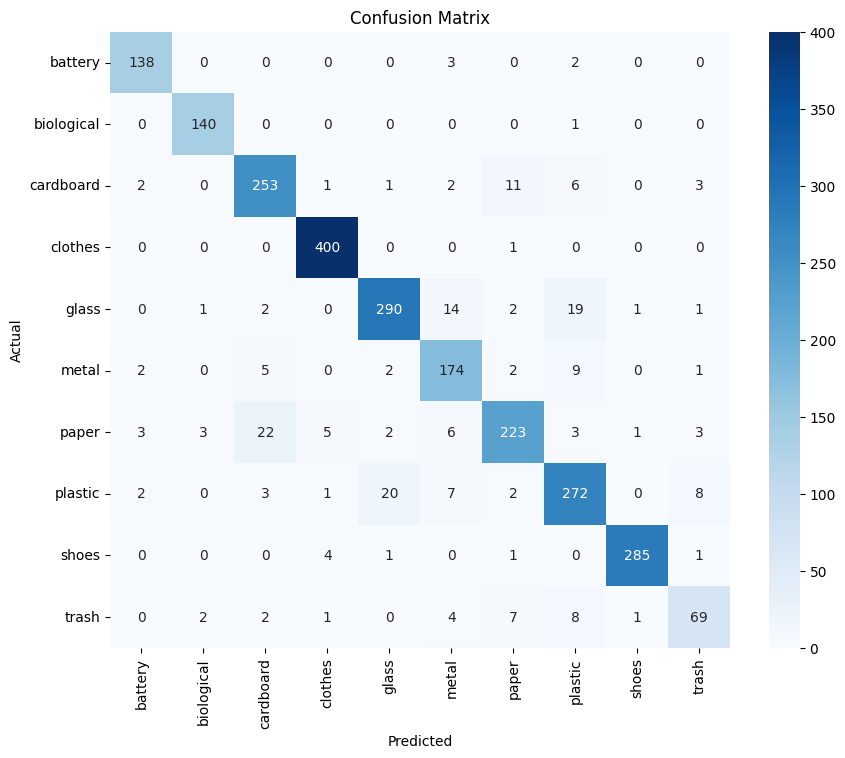

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The model excels on visually distinctive classes (clothes, shoes, biological) but confuses similar materials (glass/plastic, paper/cardboard), with trash showing the lowest performance due to its heterogeneous nature.

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)

print(report)

              precision    recall  f1-score   support

     battery       0.94      0.97      0.95       143
  biological       0.96      0.99      0.98       141
   cardboard       0.88      0.91      0.89       279
     clothes       0.97      1.00      0.98       401
       glass       0.92      0.88      0.90       330
       metal       0.83      0.89      0.86       195
       paper       0.90      0.82      0.86       271
     plastic       0.85      0.86      0.86       315
       shoes       0.99      0.98      0.98       292
       trash       0.80      0.73      0.77        94

    accuracy                           0.91      2461
   macro avg       0.90      0.90      0.90      2461
weighted avg       0.91      0.91      0.91      2461



Overall test accuracy is 91% with balanced performance (macro F1: 0.90), though trash class (F1: 0.77) and similar-looking materials remain challenging.

In [ ]:
image_paths = [
    "images/plastic.jpeg",
    "images/glass.jpeg",
    "images/metal.jpeg",
    "images/trash.jpeg",
    "images/cardboard.jpeg"
]

for img_path in image_paths:
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model_tl.predict(img_array)
    pred_class = class_names[np.argmax(pred)]

    print(f"{img_path} -> Predicted: {pred_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
images/plastic.jpeg → Predicted: plastic
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
images/glass.jpeg → Predicted: cardboard
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
images/metal.jpeg → Predicted: plastic
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
images/trash.jpeg → Predicted: paper
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
images/cardboard.jpeg → Predicted: cardboard


In [40]:
image_paths = [
    "images/plastic.jpeg",
    "images/glass.jpeg",
    "images/metal.jpeg",
    "images/trash.jpeg",
    "images/cardboard.jpeg"
]

for img_path in image_paths:
    # Load image
    img = load_img(img_path, target_size=(224, 224))

    # Convert to grayscale then back to RGB (important for model)
    img = img.convert("L").convert("RGB")

    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model_tl.predict(img_array)
    pred_class = class_names[np.argmax(pred)]

    print(f"{img_path} -> Grayscale Predicted: {pred_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 912ms/step
images/plastic.jpeg -> Grayscale Predicted: glass
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
images/glass.jpeg -> Grayscale Predicted: metal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
images/metal.jpeg -> Grayscale Predicted: plastic
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
images/trash.jpeg -> Grayscale Predicted: paper
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
images/cardboard.jpeg -> Grayscale Predicted: cardboard


Real-world predictions show the model performs well in controlled settings but struggles with cluttered images and similar-looking materials (e.g., glass→cardboard, metal→plastic), highlighting limitations of relying on visual texture alone.

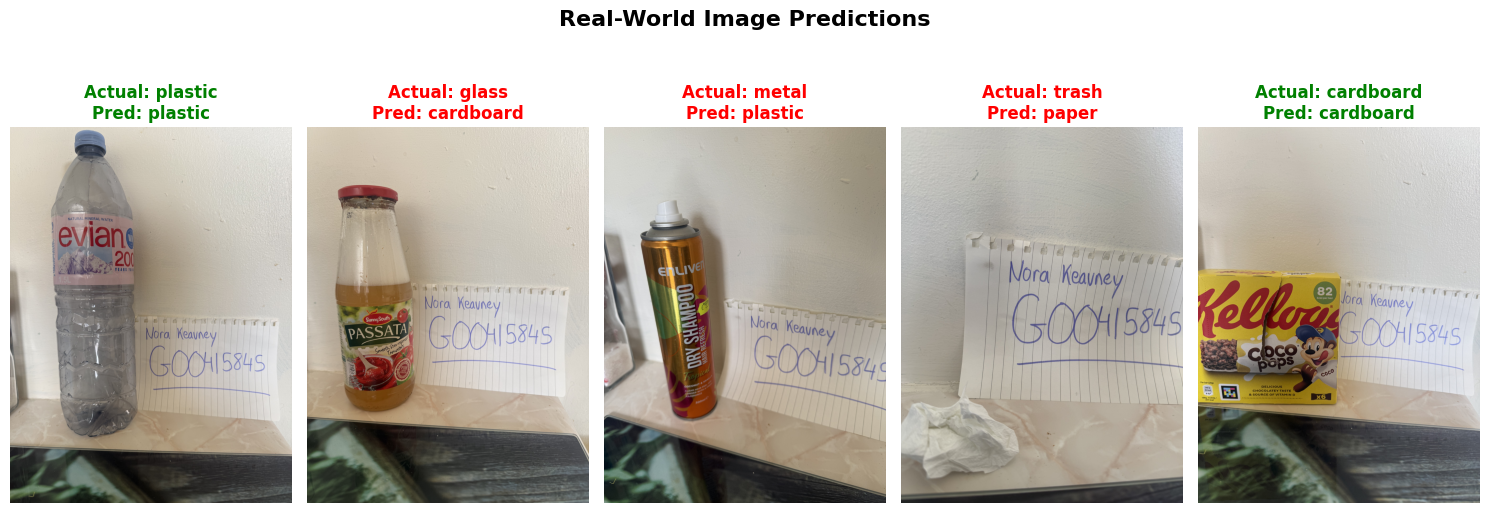

In [ ]:
images = ["plastic.jpeg", "glass.jpeg", "metal.jpeg", "trash.jpeg", "cardboard.jpeg"]

# ADD THIS (actual labels - you know these from your test)
actuals = ["plastic", "glass", "metal", "trash", "cardboard"]

preds = ["plastic", "cardboard", "plastic", "paper", "cardboard"]

plt.figure(figsize=(15, 6))  # wider for clean row

for i, (img, actual, pred) in enumerate(zip(images, actuals, preds)):
    plt.subplot(1, 5, i + 1)  # ONE ROW

    image = Image.open(f"images/{img}").convert("RGB").rotate(270, expand=True)
    plt.imshow(image)

    # COLOR CODE (very nice touch for report)
    color = "green" if actual == pred else "red"

    plt.title(
        f"Actual: {actual}\nPred: {pred}",
        fontsize=12,
        color=color,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle("Real-World Image Predictions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("real_world_predictions_clean.png", dpi=300)
plt.show()

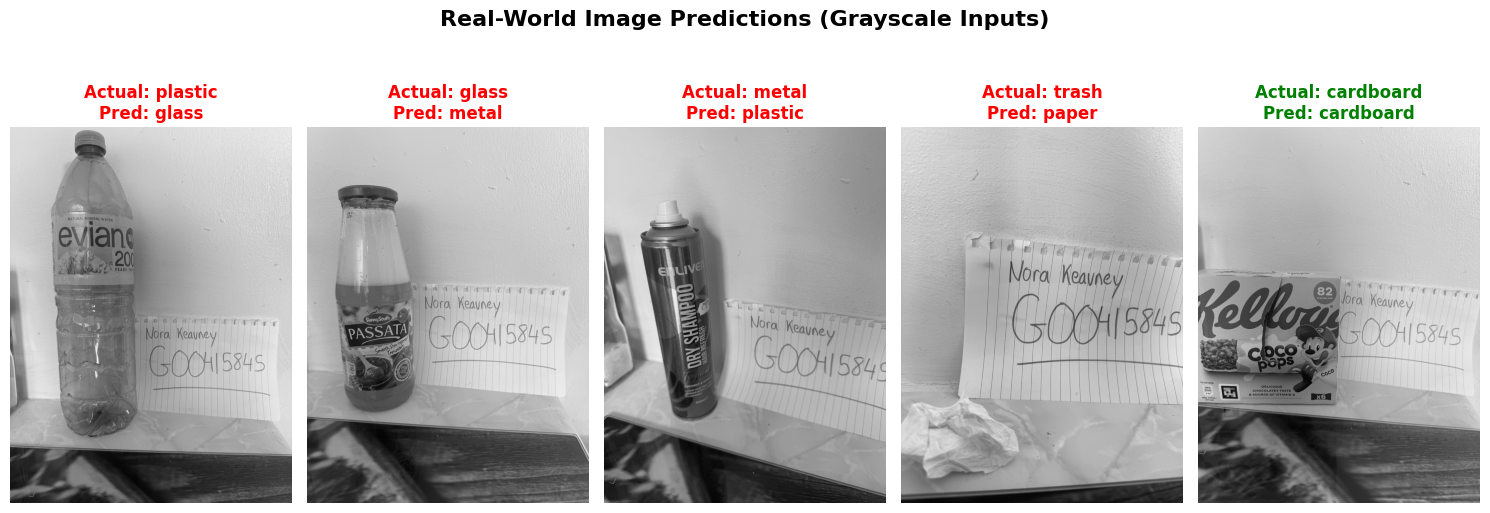

In [41]:
images = ["plastic.jpeg", "glass.jpeg", "metal.jpeg", "trash.jpeg", "cardboard.jpeg"]

# Actual labels
actuals = ["plastic", "glass", "metal", "trash", "cardboard"]

# grayscale predictions 
preds = ["glass", "metal", "plastic", "paper", "cardboard"]

plt.figure(figsize=(15, 6))  

for i, (img, actual, pred) in enumerate(zip(images, actuals, preds)):
    plt.subplot(1, 5, i + 1) 

    # convert to grayscale
    image = Image.open(f"images/{img}") \
                 .convert("L") \
                 .rotate(270, expand=True)

    plt.imshow(image, cmap="gray") 
    # same color logic as before
    color = "green" if actual == pred else "red"

    plt.title(
        f"Actual: {actual}\nPred: {pred}",
        fontsize=12,
        color=color,
        fontweight="bold"
    )

    plt.axis("off")

plt.suptitle("Real-World Image Predictions (Grayscale Inputs)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("real_world_predictions_grayscale.png", dpi=300)
plt.show()